## Notebook 5 - CatBoost & Ensemble

In [1]:
# 1. INSTALL & IMPORTS

!pip install catboost --quiet

import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostRegressor


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [2]:
# 2. LOAD DATA

df = pd.read_csv("rossmann_features.csv", parse_dates=['Date'])

with open("feature_cols.txt") as f:
    FEATURE_COLS = [line.strip() for line in f.readlines()]


In [3]:
# 3. TIME SPLIT (same cutoff as XGBoost)

cutoff_date = "2015-06-01"
train_df = df[df['Date'] < cutoff_date].copy()
valid_df = df[df['Date'] >= cutoff_date].copy()

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)


Train shape: (785727, 35)
Valid shape: (58611, 35)


In [4]:
# 4. PREPARE CATBOOST (log target)

train_df['log_sales'] = np.log1p(train_df['Sales'])
valid_df['log_sales'] = np.log1p(valid_df['Sales'])

X_train = train_df[FEATURE_COLS]
y_train = train_df['log_sales']
X_valid = valid_df[FEATURE_COLS]
y_valid = valid_df['log_sales']


In [5]:
# 5. RMSPE FUNCTION

def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask   = y_true > 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


In [6]:
# 6. CATBOOST MODEL

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid)
)

cat_preds_valid = cat_model.predict(X_valid)
valid_df['cat_pred'] = np.expm1(cat_preds_valid)

cat_preds_train = cat_model.predict(X_train)
train_df['cat_pred'] = np.expm1(cat_preds_train)


0:	learn: 0.4074056	test: 0.3979325	best: 0.3979325 (0)	total: 207ms	remaining: 3m 26s
100:	learn: 0.0250454	test: 0.0174138	best: 0.0174138 (100)	total: 14.7s	remaining: 2m 10s
200:	learn: 0.0188939	test: 0.0137491	best: 0.0137491 (200)	total: 28.6s	remaining: 1m 53s
300:	learn: 0.0170605	test: 0.0129546	best: 0.0129546 (300)	total: 42.6s	remaining: 1m 38s
400:	learn: 0.0158611	test: 0.0124741	best: 0.0124741 (400)	total: 56.5s	remaining: 1m 24s
500:	learn: 0.0149996	test: 0.0121834	best: 0.0121834 (500)	total: 1m 10s	remaining: 1m 10s
600:	learn: 0.0143924	test: 0.0119608	best: 0.0119608 (600)	total: 1m 25s	remaining: 56.9s
700:	learn: 0.0138816	test: 0.0117671	best: 0.0117671 (700)	total: 1m 40s	remaining: 42.8s
800:	learn: 0.0133729	test: 0.0116261	best: 0.0116261 (800)	total: 1m 54s	remaining: 28.5s
900:	learn: 0.0129880	test: 0.0114852	best: 0.0114849 (899)	total: 2m 9s	remaining: 14.2s
999:	learn: 0.0126367	test: 0.0113466	best: 0.0113464 (998)	total: 2m 23s	remaining: 0us

best

                feature  importance
22               avg_4w   52.619928
26               dev_4w   42.452858
24            median_4w    4.365426
21              lag_365    0.092941
23               std_4w    0.080999
25               avg_1w    0.073351
1             DayOfWeek    0.038542
18                lag_7    0.032061
5                 Month    0.028686
12  CompetitionDistance    0.025710


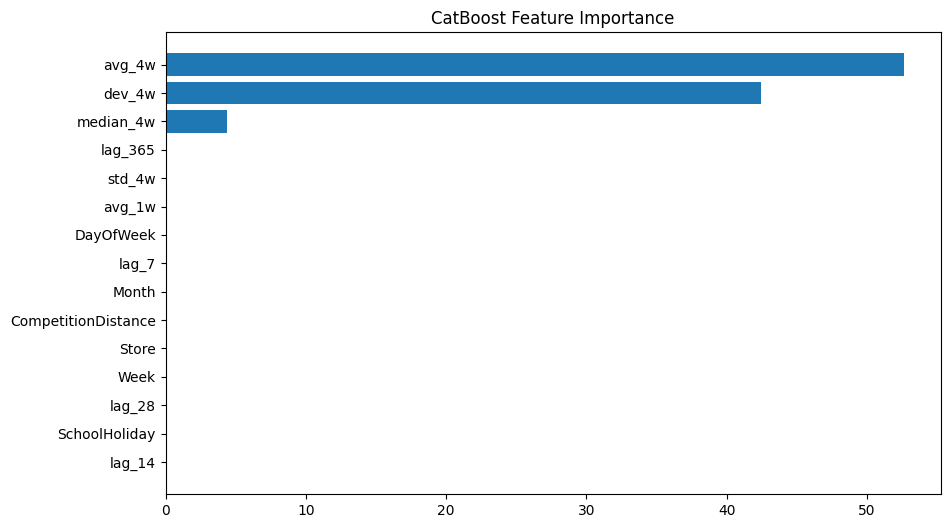

In [7]:
# CATBOOST FEATURE IMPORTANCE

import matplotlib.pyplot as plt

cat_importance = cat_model.get_feature_importance()
cat_features = X_train.columns

imp_df = pd.DataFrame({
    'feature': cat_features,
    'importance': cat_importance
}).sort_values(by='importance', ascending=False)

print(imp_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(imp_df['feature'][:15][::-1], imp_df['importance'][:15][::-1])
plt.title("CatBoost Feature Importance")
plt.show()

In [8]:
# 7. LOAD XGBOOST PREDICTIONS

xgb_valid = pd.read_csv("xgb_predictions.csv", parse_dates=['Date'])
valid_df = valid_df.merge(xgb_valid[['Store','Date','xgb_pred']], on=['Store','Date'], how='left')
valid_df['xgb_pred'] = valid_df['xgb_pred'].fillna(valid_df['Sales'])

# Generate XGBoost predictions on training set using saved model
xgb_model = joblib.load("xgboost_model.pkl")
train_df['xgb_pred'] = np.expm1(xgb_model.predict(X_train))


In [9]:
# 8. INDIVIDUAL SCORES

xgb_score = rmspe(valid_df['Sales'], valid_df['xgb_pred'])
cat_score  = rmspe(valid_df['Sales'], valid_df['cat_pred'])
print("XGBoost RMSPE (test):", xgb_score)
print("CatBoost RMSPE (test):", cat_score)


XGBoost RMSPE (test): 0.011227085704485964
CatBoost RMSPE (test): 0.011205091662749094


In [10]:
# 9. OPTIMAL WEIGHTED ENSEMBLE (inverse-error weights)

xgb_weight = 1 / (xgb_score + 1e-8)
cat_weight  = 1 / (cat_score  + 1e-8)
total       = xgb_weight + cat_weight
xgb_w = xgb_weight / total
cat_w = cat_weight  / total
print(f"Optimal weights: XGB={xgb_w:.3f}, Cat={cat_w:.3f}")

valid_df['pred'] = xgb_w * valid_df['xgb_pred'] + cat_w * valid_df['cat_pred']
train_df['pred'] = xgb_w * train_df['xgb_pred'] + cat_w * train_df['cat_pred']

ensemble_score = rmspe(valid_df['Sales'], valid_df['pred'])
print("Ensemble RMSPE (test):", ensemble_score)


Optimal weights: XGB=0.500, Cat=0.500
Ensemble RMSPE (test): 0.010382188776269086


 NOTE: Ensemble weights are ~0.5/0.5 because XGB and CatBoost have nearly identical RMSPE

In [11]:
# MODEL COMPARISON


print("\nModel Comparison:")
print("XGBoost RMSPE :", xgb_score)
print("CatBoost RMSPE:", cat_score)
print("Ensemble RMSPE:", ensemble_score)


Model Comparison:
XGBoost RMSPE : 0.011227085704485964
CatBoost RMSPE: 0.011205091662749094
Ensemble RMSPE: 0.010382188776269086


In [12]:
# 10. SAVE FULL PREDICTIONS (TRAIN + TEST)

all_preds = pd.concat([
    train_df[['Store','Date','Sales','pred']],
    valid_df[['Store','Date','Sales','pred']]
], axis=0).sort_values(['Store','Date']).reset_index(drop=True)

all_preds.to_csv("final_predictions_full.csv", index=False)
valid_df[['Store','Date','Sales','pred']].to_csv("final_predictions.csv", index=False)

print("Saved: final_predictions_full.csv (train + test combined)", len(all_preds), "rows")
print("Saved: final_predictions.csv (test only)")


Saved: final_predictions_full.csv (train + test combined) 844338 rows
Saved: final_predictions.csv (test only)
